In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv("animal_species.csv")
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()
df.skew(numeric_only=True)
num=df.select_dtypes(include=["number"]).columns
df.duplicated()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   animal_id  200 non-null    int64  
 1   weight_kg  200 non-null    float64
 2   height_cm  200 non-null    float64
 3   habitat    200 non-null    str    
 4   diet_type  200 non-null    str    
 5   species    200 non-null    str    
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB


0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [4]:
df

,animal_id,weight_kg,height_cm,habitat,diet_type,species
0,1,184.0,108.8,Savanna,Carnivore,Lion
1,2,978.9,540.6,Grassland,Herbivore,Giraffe
2,3,154.7,121.5,Savanna,Carnivore,Lion
3,4,5860.5,265.1,Savanna,Herbivore,Elephant
4,5,4206.9,337.1,Forest,Herbivore,Elephant
...,...,...,...,...,...,...
195,196,834.7,541.9,Grassland,Herbivore,Giraffe
196,197,73.6,83.3,Forest,Carnivore,Wolf
197,198,1.3,28.6,Grassland,Herbivore,Rabbit
198,199,2.6,21.7,Forest,Herbivore,Rabbit


In [ ]:
pd.crosstab(df["habitat"],df["species"])
pd.crosstab(df["habitat"],df["diet_type"])

diet_type,Carnivore,Herbivore,Omnivore
habitat,,,
Forest,16,25,24
Grassland,14,41,12
Savanna,11,34,0
Tundra,9,0,14


In [6]:
df["animal_id"].unique()
df["weight_kg"].unique()
df["height_cm"].unique()
df["habitat"].unique()
df["diet_type"].unique()
df["species"].unique()

<StringArray>
['Lion', 'Giraffe', 'Elephant', 'Fox', 'Wolf', 'Bear', 'Zebra', 'Rabbit']
Length: 8, dtype: str

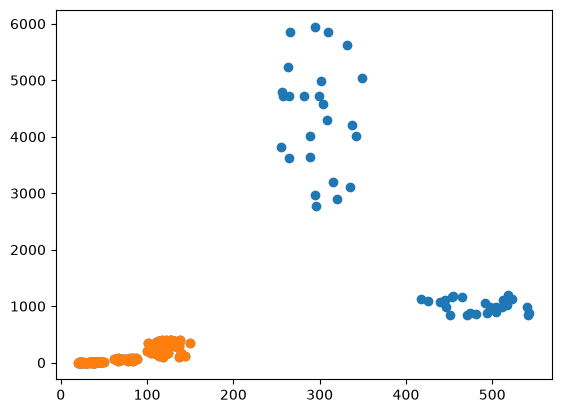

In [7]:
sample=df[np.where(df["species"].isin(["Lion","Rabbit","Wolf","Fox","Zebra","Bear"]),True,False)]
sample
plt.scatter(df["height_cm"],df["weight_kg"])
plt.scatter(sample["height_cm"],sample["weight_kg"])

<Axes: xlabel='weight_kg', ylabel='Count'>

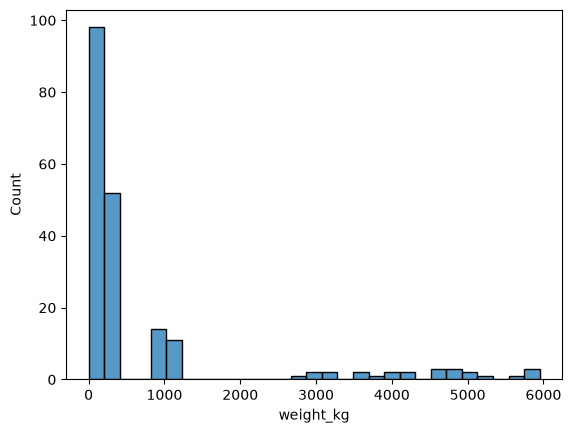

In [8]:
sns.histplot(x="weight_kg",data=df)

<Axes: xlabel='height_cm', ylabel='Count'>

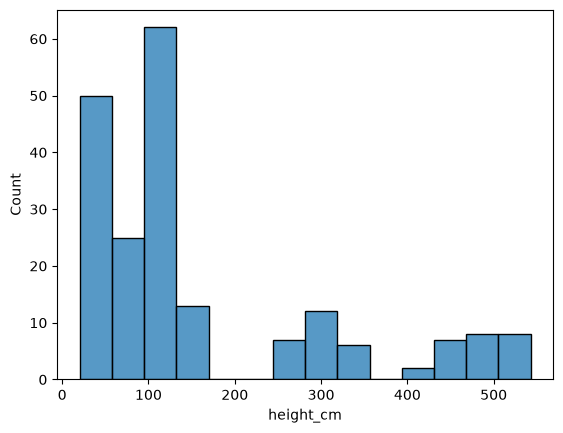

In [9]:
sns.histplot(x="height_cm",data=df)

<Axes: xlabel='habitat', ylabel='count'>

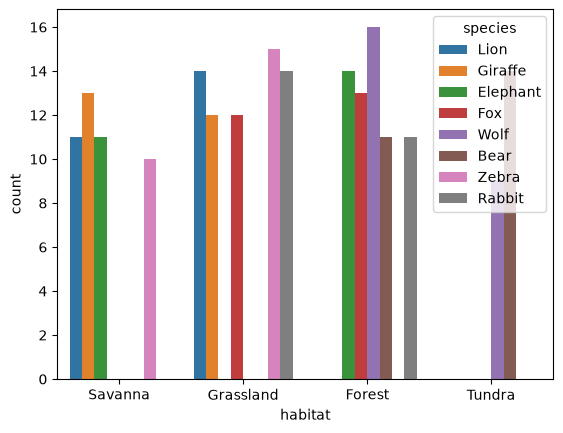

In [10]:
sns.countplot(x="habitat",hue="species",data=df)

<Axes: xlabel='species', ylabel='count'>

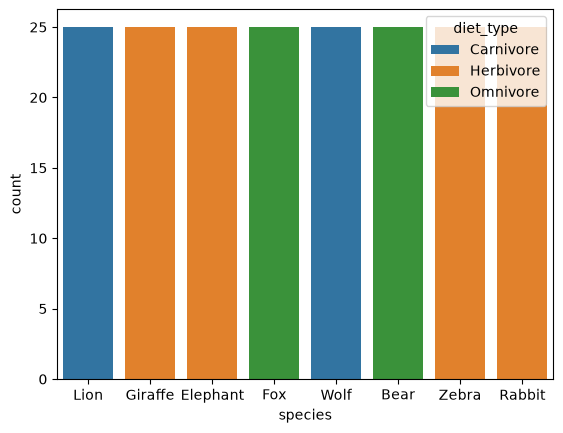

In [11]:
sns.countplot(x="species",hue="diet_type",data=df)

<Axes: xlabel='species', ylabel='count'>

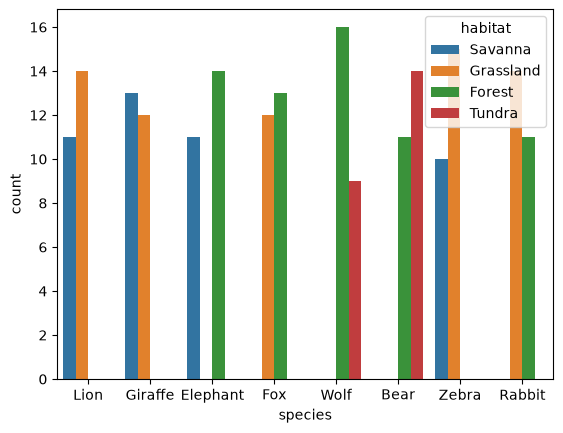

In [12]:
sns.countplot(x="species",hue="habitat",data=df)

<Axes: xlabel='species', ylabel='habitat'>

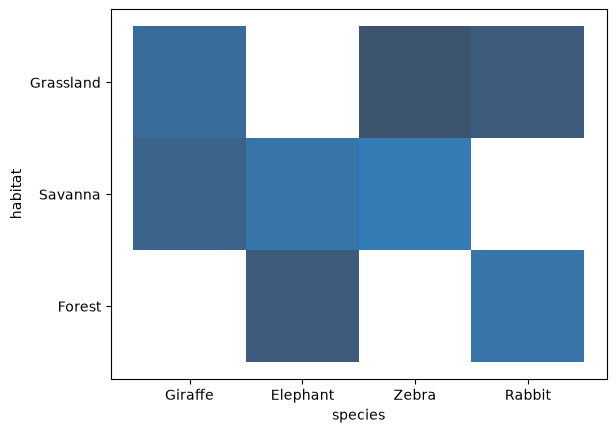

In [13]:
sample=df[df["diet_type"]=="Herbivore"]
sns.histplot(x="species",y="habitat",data=sample)

<Axes: ylabel='height_cm'>

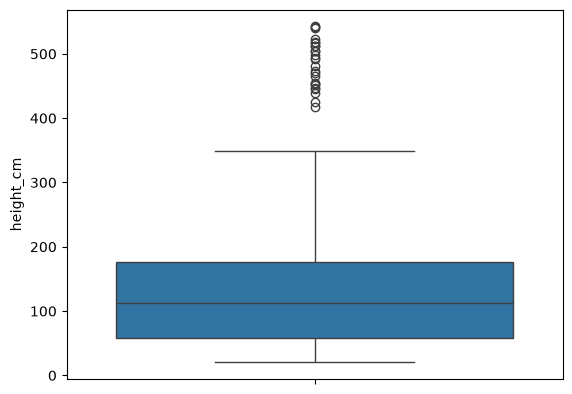

In [14]:
sns.boxplot(df["height_cm"])

<Axes: ylabel='weight_kg'>

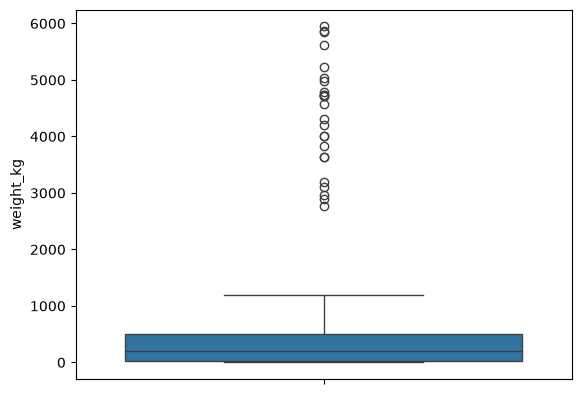

In [15]:
sns.boxplot(df["weight_kg"])

In [16]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
df

,animal_id,weight_kg,height_cm,habitat,diet_type,species
0,1,184.0,108.8,Savanna,Carnivore,Lion
1,2,978.9,540.6,Grassland,Herbivore,Giraffe
2,3,154.7,121.5,Savanna,Carnivore,Lion
3,4,5860.5,265.1,Savanna,Herbivore,Elephant
4,5,4206.9,337.1,Forest,Herbivore,Elephant
...,...,...,...,...,...,...
195,196,834.7,541.9,Grassland,Herbivore,Giraffe
196,197,73.6,83.3,Forest,Carnivore,Wolf
197,198,1.3,28.6,Grassland,Herbivore,Rabbit
198,199,2.6,21.7,Forest,Herbivore,Rabbit


In [17]:
X=pd.get_dummies(df.drop(columns=["species"]),dtype=int)
X

,animal_id,weight_kg,height_cm,habitat_Forest,habitat_Grassland,habitat_Savanna,habitat_Tundra,diet_type_Carnivore,diet_type_Herbivore,diet_type_Omnivore
0,1,184.0,108.8,0,0,1,0,1,0,0
1,2,978.9,540.6,0,1,0,0,0,1,0
2,3,154.7,121.5,0,0,1,0,1,0,0
3,4,5860.5,265.1,0,0,1,0,0,1,0
4,5,4206.9,337.1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
195,196,834.7,541.9,0,1,0,0,0,1,0
196,197,73.6,83.3,1,0,0,0,1,0,0
197,198,1.3,28.6,0,1,0,0,0,1,0
198,199,2.6,21.7,1,0,0,0,0,1,0


In [18]:
y=df["species"]
#y=pd.get_dummies(y,dtype=int)
y
#print(help(pd.get_dummies))


0          Lion
1       Giraffe
2          Lion
3      Elephant
4      Elephant
         ...   
195     Giraffe
196        Wolf
197      Rabbit
198      Rabbit
199    Elephant
Name: species, Length: 200, dtype: str

In [19]:
plt.figure(figsize=(10,10))
sample.corr(numeric_only=True)

,animal_id,weight_kg,height_cm
animal_id,1.000000,-0.158559,0.030144
weight_kg,-0.158559,1.000000,0.387477
height_cm,0.030144,0.387477,1.000000


<Figure size 1000x1000 with 0 Axes>

In [20]:
sample.columns

Index(['animal_id', 'weight_kg', 'height_cm', 'habitat', 'diet_type',
       'species'],
      dtype='str')

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler=StandardScaler()
X


array([[-1.7234121 , -0.4147138 , -0.35193353, ...,  1.73205081,
        -1.        , -0.57735027],
       [-1.70609137,  0.14004922,  2.60394945, ..., -0.57735027,
         1.        , -0.57735027],
       [-1.68877065, -0.43516236, -0.2649958 , ...,  1.73205081,
        -1.        , -0.57735027],
       ...,
       [ 1.68877065, -0.54222066, -0.90094191, ..., -0.57735027,
         1.        , -0.57735027],
       [ 1.70609137, -0.54131339, -0.9481758 , ..., -0.57735027,
         1.        , -0.57735027],
       [ 1.7234121 ,  3.60897566,  0.91653594, ..., -0.57735027,
         1.        , -0.57735027]], shape=(200, 10))

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model.fit(x_train,y_train)
print("Traing data shape ",x_train.shape)
print("Testing data shape",x_test.shape)
print("y_train shape is",y_train.shape)
print("y_test shape is ",y_test.shape)

Traing data shape  (60, 10)
Testing data shape (60, 10)
y_train shape is (140,)
y_test shape is  (60,)


In [30]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [31]:

from sklearn.metrics import (

    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score

)

In [34]:
y_pred=model.predict(x_test)
y_pred
y_prob=model.predict_proba(x_test)
np.round(y_prob,3)

array([[0.975, 0.001, 0.013, 0.002, 0.   , 0.   , 0.007, 0.002],
       [0.001, 0.001, 0.013, 0.003, 0.942, 0.005, 0.023, 0.012],
       [0.002, 0.005, 0.003, 0.004, 0.94 , 0.001, 0.028, 0.018],
       [0.375, 0.002, 0.582, 0.001, 0.001, 0.022, 0.015, 0.002],
       [0.001, 0.002, 0.018, 0.003, 0.007, 0.565, 0.001, 0.404],
       [0.751, 0.004, 0.222, 0.003, 0.001, 0.005, 0.012, 0.002],
       [0.006, 0.988, 0.   , 0.006, 0.   , 0.   , 0.001, 0.   ],
       [0.001, 0.002, 0.017, 0.004, 0.007, 0.558, 0.001, 0.412],
       [0.968, 0.001, 0.016, 0.002, 0.   , 0.001, 0.01 , 0.002],
       [0.02 , 0.   , 0.948, 0.001, 0.012, 0.006, 0.   , 0.013],
       [0.002, 0.004, 0.003, 0.005, 0.934, 0.001, 0.032, 0.019],
       [0.027, 0.   , 0.935, 0.001, 0.012, 0.009, 0.   , 0.015],
       [0.355, 0.002, 0.601, 0.001, 0.001, 0.024, 0.015, 0.002],
       [0.   , 0.002, 0.021, 0.002, 0.007, 0.581, 0.001, 0.386],
       [0.005, 0.013, 0.   , 0.946, 0.001, 0.   , 0.   , 0.035],
       [0.019, 0.953, 0. 

In [36]:
result=pd.DataFrame({
    "Actual values":y_test,
    "predicted values":y_pred
})
result

,Actual values,predicted values
95,Bear,Bear
15,Lion,Lion
30,Lion,Lion
158,Fox,Fox
128,Rabbit,Rabbit
115,Bear,Bear
69,Elephant,Elephant
170,Rabbit,Rabbit
174,Bear,Bear
45,Fox,Fox


In [37]:
accuracy_score(y_test,y_pred)

1.0

In [38]:
confusion_matrix(y_test,y_pred)

array([[ 8,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  9,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 10,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  8,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 10,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  5,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  4]])

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        Bear       1.00      1.00      1.00         8
    Elephant       1.00      1.00      1.00         6
         Fox       1.00      1.00      1.00         9
     Giraffe       1.00      1.00      1.00        10
        Lion       1.00      1.00      1.00         8
      Rabbit       1.00      1.00      1.00        10
        Wolf       1.00      1.00      1.00         5
       Zebra       1.00      1.00      1.00         4

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

